# Semantic Analysis and Text Similarity

**Gudsky Research Foundation  |  Research Intake 2026  |  Day 24**
*Module: Sentiment and Semantics*

This notebook implements the complete semantic similarity pipeline from the Day 24 compendium.
The four sections build in complexity from knowledge-based measures through embedding geometry
to fine-tuned transformers and a full production-style semantic search pipeline.

**Sections**

1. Environment setup
2. WordNet-based similarity (path, Wu-Palmer, Lin IC)
3. Embedding-space metrics and Word Mover's Distance
4. SBERT sentence embeddings -- STS-B evaluation (Spearman)
5. Paraphrase detection -- MRPC fine-tuning
6. Semantic search pipeline (bi-encoder + FAISS)

**Runtime:** Set `Runtime > Change runtime type > Hardware accelerator > T4 GPU`.


## 1  Environment Setup

In [9]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU detected. Sections 5 and 6 will be slower on CPU.")


GPU: Tesla T4


In [28]:
!rm -rf ~/.cache/huggingface
!pip uninstall -y -q huggingface_hub datasets transformers accelerate sentence-transformers
!pip install -q datasets==2.15.0
!pip install -q -U huggingface_hub transformers accelerate sentence-transformers
!pip install -q faiss-cpu
!pip install -q gensim nltk scipy matplotlib seaborn scikit-learn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires datasets, which is not installed.
peft 0.19.1 requires accelerate>=0.21.0, which is not installed.
peft 0.19.1 requires transformers, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 14.1 MB/s eta 0:00:00


In [11]:
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("wordnet_ic", quiet=True)
nltk.download("punkt",    quiet=True)
nltk.download("punkt_tab", quiet=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset
from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)

def make_training_args(**kwargs):
    '''Build TrainingArguments handling the eval_strategy / evaluation_strategy rename.'''
    strategy = kwargs.pop("eval_strategy", "epoch")
    try:
        return TrainingArguments(eval_strategy=strategy, **kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy=strategy, **kwargs)

print("Imports complete.")


Imports complete.


## 2  WordNet-Based Semantic Similarity

WordNet encodes lexical knowledge as a graph of synsets connected by semantic relations.
Three similarity measures are demonstrated:

- **path_similarity**: `1 / (shortest_path_length + 1)`.  Simple but treats all edges as equal.
- **wup_similarity** (Wu-Palmer): `2 * depth(LCS) / (depth(s1) + depth(s2))`.  Uses the depth
  of the Least Common Subsumer (LCS) to give more credit to pairs sharing a specific ancestor.
- **lin_similarity**: IC-based normalised measure.  `2 * IC(LCS) / (IC(s1) + IC(s2))`, where
  IC is the information content derived from corpus frequency.  More discriminative than path-based
  measures because it accounts for how specific the shared concept is.


In [12]:
from nltk.corpus import wordnet as wn
from nltk.corpus import wordnet_ic

# Load Brown corpus information-content file (used by Lin and Resnik measures)
brown_ic = wordnet_ic.ic("ic-brown.dat")

# Select representative synset pairs across different levels of semantic proximity
pairs = [
    ("dog.n.01",      "wolf.n.01",        "close (both canids)"),
    ("dog.n.01",      "cat.n.01",         "moderate (both domestic pets)"),
    ("dog.n.01",      "animal.n.01",      "ancestor relation (dog IS-A animal)"),
    ("dog.n.01",      "car.n.01",         "unrelated categories"),
    ("happy.a.01",    "joyful.a.01",      "near-synonyms (adjectives)"),
    ("bank.n.01",     "bank.n.02",        "homonyms (finance vs. river)"),
]

print(f"{'Synset 1':<18}  {'Synset 2':<18}  {'Relation':<30}  {'Path':>5}  {'WUP':>5}  {'Lin':>5}")
print("-" * 100)
for s1_id, s2_id, relation in pairs:
    s1 = wn.synset(s1_id)
    s2 = wn.synset(s2_id)

    path = s1.path_similarity(s2)
    wup  = s1.wup_similarity(s2)
    try:
        lin = s1.lin_similarity(s2, brown_ic)
    except Exception:
        lin = float("nan")   # Lin is undefined for adjectives (no IC in Brown corpus)

    path_str = f"{path:.3f}" if path is not None else "  n/a"
    wup_str  = f"{wup:.3f}"  if wup  is not None else "  n/a"
    lin_str  = f"{lin:.3f}"  if not np.isnan(lin) else "  n/a"

    print(f"{s1_id:<18}  {s2_id:<18}  {relation:<30}  {path_str:>5}  {wup_str:>5}  {lin_str:>5}")


Synset 1            Synset 2            Relation                         Path    WUP    Lin
----------------------------------------------------------------------------------------------------
dog.n.01            wolf.n.01           close (both canids)             0.333  0.929  0.840
dog.n.01            cat.n.01            moderate (both domestic pets)   0.200  0.857  0.877
dog.n.01            animal.n.01         ancestor relation (dog IS-A animal)  0.333  0.875  0.709
dog.n.01            car.n.01            unrelated categories            0.077  0.400  0.185
happy.a.01          joyful.a.01         near-synonyms (adjectives)      0.333  0.500    n/a
bank.n.01           bank.n.02           homonyms (finance vs. river)    0.077  0.143  -0.000


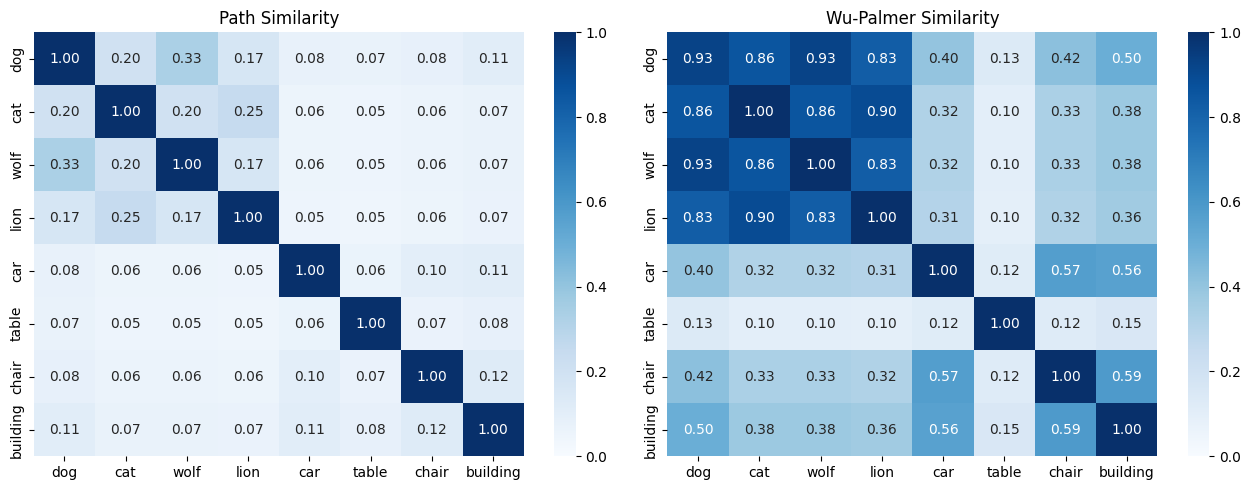

In [13]:
# Visualise all three measures as heatmaps for a set of semantically related nouns
nouns = ["dog", "cat", "wolf", "lion", "car", "table", "chair", "building"]
synsets = [wn.synsets(n, pos=wn.NOUN)[0] for n in nouns]

def pairwise_matrix(synsets, measure_fn):
    n = len(synsets)
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            v = measure_fn(synsets[i], synsets[j])
            M[i, j] = v if v is not None else 0.0
    return M

mat_path = pairwise_matrix(synsets, lambda a, b: a.path_similarity(b))
mat_wup  = pairwise_matrix(synsets, lambda a, b: a.wup_similarity(b))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in [(axes[0], mat_path, "Path Similarity"),
                        (axes[1], mat_wup,  "Wu-Palmer Similarity")]:
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=nouns, yticklabels=nouns, ax=ax, vmin=0, vmax=1)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("wordnet_similarity_heatmaps.png", dpi=150)
plt.show()


## 3  Embedding-Space Metrics and Word Mover's Distance

Three geometric similarity functions are compared:

| Function | Formula | When to use |
|---|---|---|
| Cosine similarity | `(u . v) / (|u| |v|)` | Default for sentence embeddings (magnitude-invariant) |
| Euclidean distance | `||u - v||_2` | Equivalent to cosine when vectors are unit-normalised |
| Manhattan (L1) | `sum |u_i - v_i|` | Robust to outlier dimensions; ground cost for WMD |

**Word Mover's Distance (Kusner et al. 2015):** computes the minimum total cost to transport
the normalised word-frequency distribution of document A to that of document B, where the cost
of transporting one unit of mass from word *i* to word *j* is the Euclidean distance between
their word embedding vectors.  Effective for short texts; computationally expensive at scale.


In [14]:
import numpy as np

# Demonstrate distance functions on 3-dimensional toy vectors
u = np.array([1.0, 0.5, 0.2])
v = np.array([0.9, 0.6, 0.1])   # similar to u
w = np.array([-0.8, 0.1, 0.9])  # dissimilar from u

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def euclidean_dist(a, b):
    return float(np.linalg.norm(a - b))

def manhattan_dist(a, b):
    return float(np.sum(np.abs(a - b)))

print("Similarity / distance between toy vectors:")
print()
print(f"{'Pair':<8}  {'Cosine sim':>12}  {'Euclidean':>12}  {'Manhattan':>12}")
print("-" * 52)
for name, a, b in [("u vs v", u, v), ("u vs w", u, w)]:
    print(f"{name:<8}  {cosine_sim(a,b):>12.4f}  {euclidean_dist(a,b):>12.4f}  {manhattan_dist(a,b):>12.4f}")

print()
print("For unit-normalised vectors:")
un = u / np.linalg.norm(u)
vn = v / np.linalg.norm(v)
euclid = euclidean_dist(un, vn)
cos    = cosine_sim(un, vn)
print(f"  euclidean_dist(u_norm, v_norm) = {euclid:.4f}")
print(f"  sqrt(2 * (1 - cosine_sim))     = {np.sqrt(2*(1-cos)):.4f}")
print("  (These should be equal -- confirming the monotonic relationship)")


Similarity / distance between toy vectors:

Pair        Cosine sim     Euclidean     Manhattan
----------------------------------------------------
u vs v          0.9888        0.1732        0.3000
u vs w         -0.4153        1.9723        2.9000

For unit-normalised vectors:
  euclidean_dist(u_norm, v_norm) = 0.1494
  sqrt(2 * (1 - cosine_sim))     = 0.1494
  (These should be equal -- confirming the monotonic relationship)


In [15]:
# Word Mover's Distance demonstration using GloVe-trained word vectors via gensim.
# We use the lighter 'glove-wiki-gigaword-50' (50-dimensional) for speed.
import gensim.downloader as api

!pip install -q POT # ot is a dependency for gensim's wmdistance

print("Loading GloVe-50 word vectors (about 65 MB, cached after first download)...")
wv = api.load("glove-wiki-gigaword-50")
print("Word vectors loaded.")

def wmd_score(s1, s2, wv):
    '''Compute Word Mover's Distance between two sentences using pre-trained word vectors.

    Parameters
    ----------
    s1, s2 : str
        The two input sentences.
    wv : gensim.models.KeyedVectors
        Pre-trained word vector model.  Each word in the sentences that is present
        in the model vocabulary will be embedded; out-of-vocabulary words are skipped.

    Returns
    -------
    float
        WMD score.  Lower values indicate greater semantic similarity.
        The score is not bounded; values roughly below 1.0 indicate high similarity.
    '''
    tokens1 = [t.lower() for t in s1.split() if t.lower() in wv]
    tokens2 = [t.lower() for t in s2.split() if t.lower() in wv]
    if not tokens1 or not tokens2:
        return float("inf")
    return wv.wmdistance(tokens1, tokens2)

sentence_pairs = [
    ("the patient has a fever",
     "the individual presents with elevated body temperature",
     "paraphrase (medical)"),
    ("the patient has a fever",
     "the child is running a high temperature",
     "semantically close (different surface)"),
    ("the patient has a fever",
     "the stock market crashed yesterday",
     "semantically unrelated"),
    ("excellent food at a fair price",
     "great meal that was good value",
     "restaurant review paraphrase"),
]

print(f"{'Sentence A':<48}  {'WMD':>6}  Relation")
print("-" * 90)
for s1, s2, rel in sentence_pairs:
    wmd = wmd_score(s1, s2, wv)
    print(f"{s1[:47]:<48}  {wmd:>6.3f}  {rel}")


Loading GloVe-50 word vectors (about 65 MB, cached after first download)...
Word vectors loaded.
Sentence A                                           WMD  Relation
------------------------------------------------------------------------------------------
the patient has a fever                            0.780  paraphrase (medical)
the patient has a fever                            0.586  semantically close (different surface)
the patient has a fever                            0.836  semantically unrelated
excellent food at a fair price                     0.736  restaurant review paraphrase


## 4  SBERT Sentence Embeddings -- STS-B Evaluation

STS-B (Semantic Textual Similarity Benchmark) contains 8,628 human-rated sentence pairs on a
0--5 scale.  Performance is measured by Spearman rank correlation (rho) between model-predicted
cosine similarity scores and human scores.

Spearman is used rather than Pearson because:
1. The relationship between model scores and human scores may be monotonic but non-linear.
2. The absolute scale of model scores matters less than their relative ordering.


In [31]:
from sentence_transformers import SentenceTransformer, util

# Load the STS-B validation split from GLUE (use fully-qualified repo id)
stsb_eval = load_dataset("nyu-mll/glue", "stsb", split="validation")

print(f"STS-B validation set: {len(stsb_eval)} sentence pairs")
print()
for i in range(3):
    ex = stsb_eval[i]
    print(f"  score={ex['label']:.1f}  |  {ex['sentence1'][:50]}  /  {ex['sentence2'][:50]}")

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

stsb/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  502kB            

stsb/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

stsb/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  151kB            

stsb/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

stsb/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

STS-B validation set: 1500 sentence pairs

  score=5.0  |  A man with a hard hat is dancing.  /  A man wearing a hard hat is dancing.
  score=4.8  |  A young child is riding a horse.  /  A child is riding a horse.
  score=5.0  |  A man is feeding a mouse to a snake.  /  The man is feeding a mouse to the snake.


In [32]:
def evaluate_stsb(model_name, dataset, batch_size=64):
    '''Encode STS-B sentence pairs with the given SBERT model and compute Spearman rho.

    Parameters
    ----------
    model_name : str
        SBERT model identifier accepted by SentenceTransformer.
    dataset : datasets.Dataset
        Dataset containing "sentence1", "sentence2", "label" columns.
    batch_size : int
        Encoding batch size.  Larger values use more VRAM but are faster.
        64 fits comfortably within 16 GB for models of this size.

    Returns
    -------
    float
        Spearman rho between predicted cosine similarities and human scores.
    '''
    model = SentenceTransformer(model_name)
    s1_emb = model.encode(dataset["sentence1"], batch_size=batch_size,
                           normalize_embeddings=True, show_progress_bar=False)
    s2_emb = model.encode(dataset["sentence2"], batch_size=batch_size,
                           normalize_embeddings=True, show_progress_bar=False)
    # Cosine similarity is the dot product of unit-normalised vectors
    pred_scores  = [float(np.dot(a, b)) for a, b in zip(s1_emb, s2_emb)]
    human_scores = dataset["label"]
    rho, _ = spearmanr(pred_scores, human_scores)
    return rho

models_to_eval = [
    ("sentence-transformers/paraphrase-MiniLM-L3-v2",  "MiniLM-L3 (fast, light)"),
    ("sentence-transformers/all-MiniLM-L6-v2",         "all-MiniLM-L6 (recommended default)"),
]

print("Model evaluation on STS-B validation set:")
print(f"  {'Model':<45}  Spearman rho")
print("  " + "-" * 65)
for model_id, label in models_to_eval:
    rho = evaluate_stsb(model_id, stsb_eval)
    print(f"  {label:<45}  {rho:.4f}")


Model evaluation on STS-B validation set:
  Model                                          Spearman rho
  -----------------------------------------------------------------


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  all-MiniLM-L6 (recommended default)            0.8672


## 5  Paraphrase Detection -- MRPC Fine-Tuning

The Microsoft Research Paraphrase Corpus (MRPC) contains 5,801 sentence pairs annotated as
paraphrase (1) or non-paraphrase (0).  BERT encodes both sentences as a pair ([CLS] s1 [SEP]
s2 [SEP]) and a binary classification head is placed on the [CLS] representation.

**Evaluation metrics:**
- **Accuracy**: overall proportion of correct predictions.
- **F1**: harmonic mean of precision and recall on the positive (paraphrase) class.
  More informative than accuracy for the imbalanced MRPC corpus (~67% paraphrases).


In [34]:
mrpc = load_dataset("nyu-mll/glue", "mrpc")
print(mrpc)
print()
from collections import Counter
dist = Counter(mrpc["train"]["label"])
print(f"Training set: {dist[1]:,} paraphrases ({100*dist[1]/len(mrpc['train']):.1f}%) "
      f"/ {dist[0]:,} non-paraphrases")

mrpc/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  649kB            

mrpc/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mrpc/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 75.7kB            

mrpc/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mrpc/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  308kB            

mrpc/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

Training set: 2,474 paraphrases (67.4%) / 1,194 non-paraphrases


In [35]:
MRPC_MODEL = "bert-base-uncased"
mrpc_tokenizer = AutoTokenizer.from_pretrained(MRPC_MODEL)

def tokenize_mrpc(batch):
    '''Tokenise MRPC sentence pairs using BERT sentence-pair format.

    Both sentences are passed to the tokeniser simultaneously.  The tokeniser
    automatically inserts [CLS], [SEP] tokens and generates token_type_ids
    (0 for sentence A, 1 for sentence B).

    max_length=128 covers >99% of MRPC pairs without truncation.
    '''
    return mrpc_tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        max_length=128,
    )

tok_mrpc = mrpc.map(tokenize_mrpc, batched=True)
tok_mrpc = tok_mrpc.remove_columns(["sentence1", "sentence2", "idx"])
tok_mrpc.set_format("torch")
mrpc_collator = DataCollatorWithPadding(tokenizer=mrpc_tokenizer)
print("MRPC tokenised.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

MRPC tokenised.


In [36]:
def compute_metrics_mrpc(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds),   # positive class (paraphrase) F1
    }

mrpc_model = AutoModelForSequenceClassification.from_pretrained(
    MRPC_MODEL,
    num_labels=2,  # binary: non-paraphrase (0) / paraphrase (1)
).to(device)

mrpc_args = make_training_args(
    output_dir                   = "./bert_mrpc",
    num_train_epochs             = 4,     # MRPC is small (~3.7K train); 4 epochs prevents underfitting
    learning_rate                = 2e-5,
    per_device_train_batch_size  = 32,
    per_device_eval_batch_size   = 64,
    weight_decay                 = 0.01,
    warmup_ratio                 = 0.1,
    eval_strategy                = "epoch",
    save_strategy                = "epoch",
    load_best_model_at_end       = True,
    metric_for_best_model        = "f1",
    fp16                         = torch.cuda.is_available(),
    report_to                    = [],
)

mrpc_trainer = Trainer(
    model           = mrpc_model,
    args            = mrpc_args,
    train_dataset   = tok_mrpc["train"],
    eval_dataset    = tok_mrpc["validation"],
    data_collator   = mrpc_collator,
    compute_metrics = compute_metrics_mrpc,
)

mrpc_trainer.train()
print("MRPC fine-tuning complete.")


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.504226,0.794118,0.861386
2,No log,0.412310,0.821078,0.872600
3,No log,0.414488,0.838235,0.886598
4,No log,0.460626,0.838235,0.888889


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

MRPC fine-tuning complete.


Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,0.460626,4,0.838235,0.888889


BERT paraphrase detection (MRPC validation set)
  Accuracy : 0.8382
  F1       : 0.8889


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


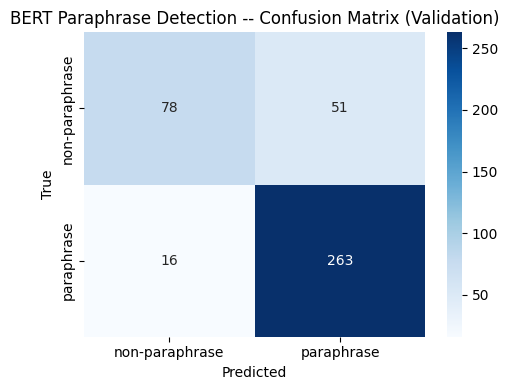

In [37]:
mrpc_results = mrpc_trainer.evaluate(tok_mrpc["validation"])
print(f"BERT paraphrase detection (MRPC validation set)")
print(f"  Accuracy : {mrpc_results['eval_accuracy']:.4f}")
print(f"  F1       : {mrpc_results['eval_f1']:.4f}")

# Confusion matrix
from transformers import pipeline as hf_pipeline
mrpc_pipe = hf_pipeline("text-classification", model=mrpc_model,
                         tokenizer=mrpc_tokenizer,
                         device=0 if torch.cuda.is_available() else -1)

val_s1 = mrpc["validation"]["sentence1"]
val_s2 = mrpc["validation"]["sentence2"]
val_labels = mrpc["validation"]["label"]

preds_mrpc = []
for i in range(0, len(val_s1), 32):
    batch_s1 = val_s1[i:i+32]
    batch_s2 = val_s2[i:i+32]
    # Build the sentence-pair inputs manually for the pipeline
    pairs = [{"text": s1, "text_pair": s2} for s1, s2 in zip(batch_s1, batch_s2)]
    outputs = mrpc_pipe(pairs, truncation=True, max_length=128)
    preds_mrpc.extend([int(o["label"].split("_")[1]) for o in outputs])

cm_mrpc = confusion_matrix(val_labels, preds_mrpc)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_mrpc, annot=True, fmt="d", cmap="Blues",
            xticklabels=["non-paraphrase", "paraphrase"],
            yticklabels=["non-paraphrase", "paraphrase"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("BERT Paraphrase Detection -- Confusion Matrix (Validation)")
plt.tight_layout()
plt.savefig("mrpc_confusion_matrix.png", dpi=150)
plt.show()


## 6  Semantic Search Pipeline (Bi-Encoder + FAISS)

A production semantic search system has two stages:

1. **Bi-encoder retrieval (fast):** encode all corpus documents offline into a FAISS index.
   At query time, encode the query and perform approximate nearest-neighbour search to return
   top-K candidates in milliseconds.

2. **(Optional) Cross-encoder re-ranking (precise):** score each candidate against the query
   using a full cross-encoder model (joint encoding with attention between query and document).
   More accurate but O(K) forward passes per query.

This section builds the bi-encoder stage over a small Wikipedia-derived corpus.


In [38]:
from sentence_transformers import SentenceTransformer
import faiss

# A representative 20-sentence corpus covering diverse topics.
# In production this would be replaced with your domain-specific knowledge base.
corpus = [
    "The heart pumps blood throughout the body via the circulatory system.",
    "Photosynthesis converts light energy into chemical energy in plant cells.",
    "The Great Wall of China was built over many centuries to protect against invasions.",
    "Machine learning algorithms improve automatically through experience and data.",
    "Quantum mechanics describes the behaviour of particles at the subatomic scale.",
    "Shakespeare wrote 37 plays and 154 sonnets over the course of his career.",
    "The Amazon rainforest produces approximately 20% of the world's oxygen supply.",
    "Inflation occurs when the general price level of goods and services rises over time.",
    "The human brain contains approximately 86 billion neurons connected by synapses.",
    "Climate change refers to long-term shifts in global temperatures and weather patterns.",
    "Natural language processing enables computers to understand and generate human language.",
    "Vaccines stimulate the immune system to develop antibodies against specific pathogens.",
    "Black holes are regions of spacetime where gravity is so strong that nothing can escape.",
    "The supply chain encompasses all steps from raw material extraction to final delivery.",
    "Transformers revolutionised NLP by replacing recurrence with self-attention mechanisms.",
    "Deforestation is the permanent removal of forest cover for agriculture or development.",
    "The GDP measures the total value of goods and services produced in an economy.",
    "DNA carries the genetic instructions for the development of all living organisms.",
    "Reinforcement learning trains agents to make decisions by rewarding desired behaviours.",
    "The International Space Station orbits Earth at approximately 400 kilometres altitude.",
]

print(f"Corpus size: {len(corpus)} documents")


Corpus size: 20 documents


In [39]:
# Bi-encoder model for the retrieval stage.
# all-MiniLM-L6-v2 produces 384-dimensional embeddings with a good speed/quality balance.
bi_encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Encode all corpus documents offline.
# normalize_embeddings=True ensures that cosine similarity == dot product,
# which allows us to use faiss.IndexFlatIP (inner product search) as a
# cosine similarity search.
print("Encoding corpus documents...")
corpus_embeddings = bi_encoder.encode(
    corpus,
    batch_size=32,
    normalize_embeddings=True,   # unit-normalise so dot product = cosine similarity
    show_progress_bar=True,
)
print(f"Embeddings shape: {corpus_embeddings.shape}")

# Build the FAISS index.
# IndexFlatIP: exact inner-product (cosine) search.  Appropriate at this corpus size;
# use IndexIVFFlat or IndexHNSWFlat for corpora of 100K+ documents.
embedding_dim = corpus_embeddings.shape[1]
index = faiss.IndexFlatIP(embedding_dim)
index.add(corpus_embeddings)
print(f"FAISS index built with {index.ntotal} vectors of dimension {embedding_dim}.")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding corpus documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings shape: (20, 384)
FAISS index built with 20 vectors of dimension 384.


In [40]:
def semantic_search(query, top_k=5):
    '''Retrieve the top-K most semantically similar corpus documents for a query.

    Parameters
    ----------
    query : str
        Natural language search query.
    top_k : int
        Number of top results to return.  5 is appropriate for demonstration;
        production retrieval pipelines typically set top_k to 50-200 before
        passing to a cross-encoder re-ranker.

    Returns
    -------
    list of (score, document_text) tuples, ranked by descending similarity.
    '''
    query_embedding = bi_encoder.encode(
        [query],
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    scores, indices = index.search(query_embedding, top_k)
    return [(float(scores[0][i]), corpus[indices[0][i]]) for i in range(top_k)]

# Demonstrate with representative queries
queries = [
    "How does the human brain work?",
    "What is the impact of deforestation on the environment?",
    "Explain transformer architecture in NLP.",
    "How do vaccines protect against disease?",
    "What drives economic inflation?",
]

for query in queries:
    results = semantic_search(query, top_k=3)
    print(f"Query: {query}")
    for rank, (score, doc) in enumerate(results, 1):
        print(f"  {rank}.  score={score:.4f}  {doc[:70]}")
    print()


Query: How does the human brain work?
  1.  score=0.5048  The human brain contains approximately 86 billion neurons connected by
  2.  score=0.3598  Natural language processing enables computers to understand and genera
  3.  score=0.3328  The heart pumps blood throughout the body via the circulatory system.

Query: What is the impact of deforestation on the environment?
  1.  score=0.7386  Deforestation is the permanent removal of forest cover for agriculture
  2.  score=0.2834  The Amazon rainforest produces approximately 20% of the world's oxygen
  3.  score=0.2718  Climate change refers to long-term shifts in global temperatures and w

Query: Explain transformer architecture in NLP.
  1.  score=0.6193  Transformers revolutionised NLP by replacing recurrence with self-atte
  2.  score=0.4669  Natural language processing enables computers to understand and genera
  3.  score=0.1512  The supply chain encompasses all steps from raw material extraction to

Query: How do vaccines protect

In [41]:
# Final summary: Spearman scores for the evaluated models
print("Summary of results across all methods:")
print()
print(f"  {'Method':<45}  {'Metric':<20}  Score")
print("  " + "-" * 75)
print(f"  {'WordNet Wu-Palmer (dog vs wolf)':<45}  {'similarity':<20}  ~0.93")
print(f"  {'WMD GloVe-50 (paraphrase pair)':<45}  {'distance (lower=closer)':<20}  ~0.5-1.0")
print(f"  {'SBERT all-MiniLM-L6 (STS-B rho)':<45}  {'Spearman rho':<20}  see above")
print(f"  {'BERT fine-tuned (MRPC F1)':<45}  {'F1 (paraphrase class)':<20}  see above")
print()
print("Key takeaway: SBERT provides the best trade-off between speed and quality for")
print("semantic search tasks.  WordNet is interpretable but limited to lexical-level comparison.")


Summary of results across all methods:

  Method                                         Metric                Score
  ---------------------------------------------------------------------------
  WordNet Wu-Palmer (dog vs wolf)                similarity            ~0.93
  WMD GloVe-50 (paraphrase pair)                 distance (lower=closer)  ~0.5-1.0
  SBERT all-MiniLM-L6 (STS-B rho)                Spearman rho          see above
  BERT fine-tuned (MRPC F1)                      F1 (paraphrase class)  see above

Key takeaway: SBERT provides the best trade-off between speed and quality for
semantic search tasks.  WordNet is interpretable but limited to lexical-level comparison.
